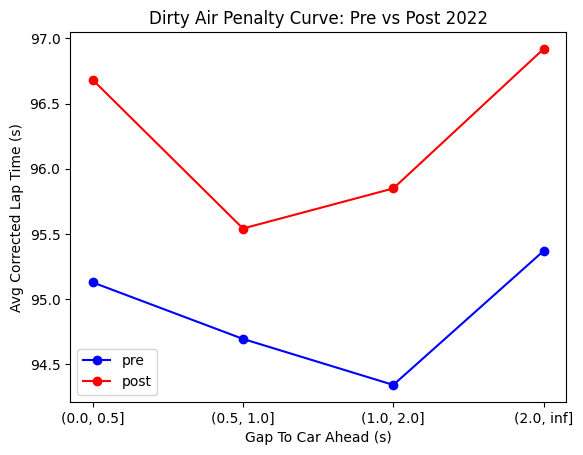

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('physics_adjusted_dataset.csv')
df['Era'] = np.where(df['Season'] < 2022, 'pre', 'post')
df['GapBin'] = pd.cut(df['GapToCarAhead'], bins=[0, 0.5, 1, 2, np.inf])

# average per circuit first, then average those circuit means by era
# so every circuit counts equally, regardless of how many laps it has
grouped = df.groupby(['Era', 'Circuit', 'GapBin'], observed=True)['CorrectedLapTime'].agg('mean')
grouped = grouped.reset_index()
grouped = grouped.groupby(['Era', 'GapBin'], observed=True)['CorrectedLapTime'].mean().reset_index()

pre = grouped[grouped['Era'] == 'pre']
post = grouped[grouped['Era'] == 'post']

plt.plot(pre['GapBin'].astype(str), pre['CorrectedLapTime'], label='pre', color='blue', marker='o')
plt.plot(post['GapBin'].astype(str), post['CorrectedLapTime'], label='post', color='red', marker='o')
plt.title("Dirty Air Penalty Curve: Pre vs Post 2022")
plt.xlabel("Gap To Car Ahead (s)")
plt.ylabel("Avg Corrected Lap Time (s)")
plt.legend()
plt.savefig('dirty_air_penalty_curve.png')
plt.show()